In [1]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [2]:
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams["figure.dpi"] = 150

## Labeled adata
From: Finalize annotations
https://github.com/aifimmunology/spatial_mouse_drg/blob/main/yano/notebooks/04_neurons/02_finalize-annotations.ipynb

In [73]:
# from projects/drg
adata_path = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/drg/data/h5ad/export_04/04c_gamma_subtypes/-draft.h5ad"
adata_ref_path = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/drg/data/h5ad/export_01/01b_filter/adata-480.h5ad" # try this instead
plot_out_dir = "/home/workspace/DRG/spatial_mouse_drg_outputs/plots"
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

In [4]:
adata = sc.read_h5ad(adata_path)

In [74]:
adata_ref = sc.read_h5ad(adata_ref_path)

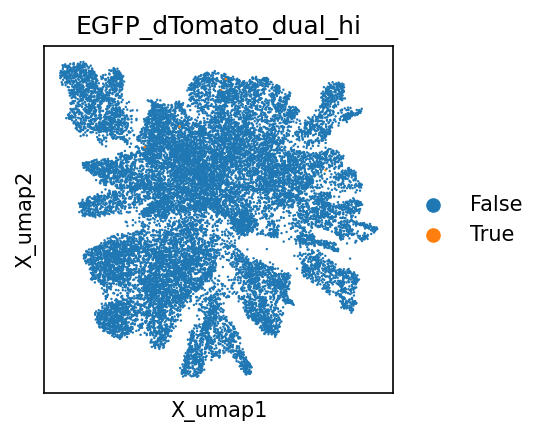

In [5]:
sc.pl.embedding(adata, basis = 'X_umap', color = 'EGFP_dTomato_dual_hi')

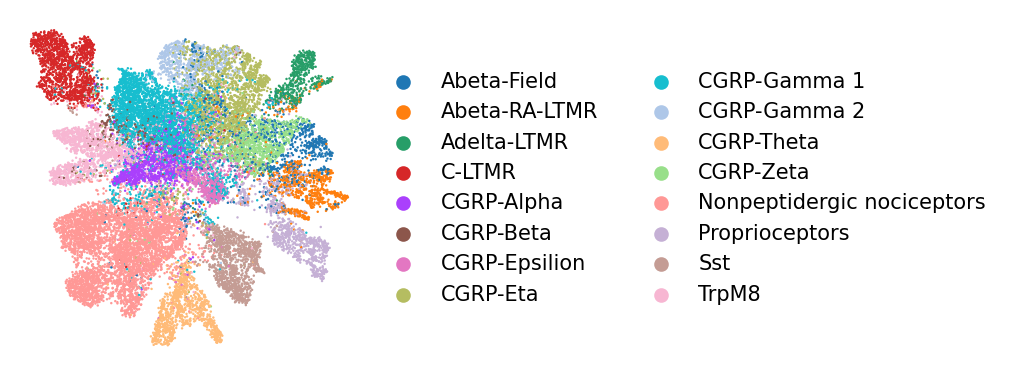

In [26]:
sc.pl.embedding(adata, basis = 'X_umap', color = 'neuron_label', frameon= False, title = '', show=False)
plt.savefig(os.path.join(plot_out_dir, 'umap_neuron_label.png'), format='png', bbox_inches='tight')


## Plot reporter group

In [32]:
import matplotlib.pyplot as plt


def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
    save_path  = None
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")  # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(os.path.join(save_path, f"umap_{col}.png"), format='png', bbox_inches='tight')

        plt.show()

In [119]:
def barplot_dual_distribution(
    adata,
    group_col="neuron_labels",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4, 2),
    fontsize=11,
    plot_counts = True,
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()

    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    # ordered counts
    sorted_counts = dual_counts.loc[stats.index]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    if plot_counts:
        ax.bar(x, sorted_counts.values, color=bar_color, alpha=0.9)
    else:
        ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha="right", fontsize=fontsize)

    # y-axis
    if plot_counts:
        ax.set_ylabel("Count", fontsize=fontsize)
    else:     
        ax.set_ylim(0, 100)  # <-- force axis to show full 0–100%
        ax.set_ylabel("% of Double+ \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    plt.subplots_adjust(bottom=0.28)
    return fig

In [33]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

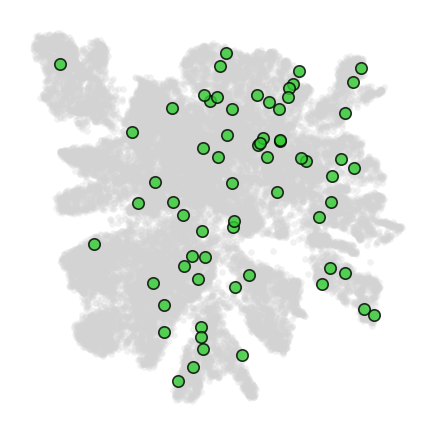

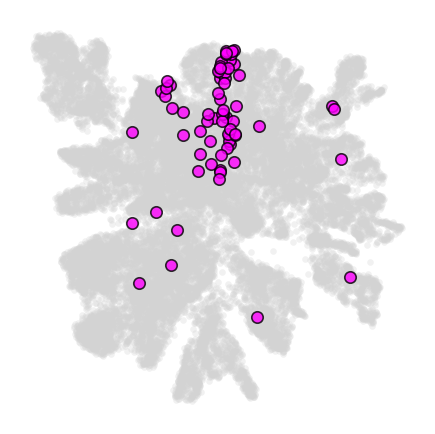

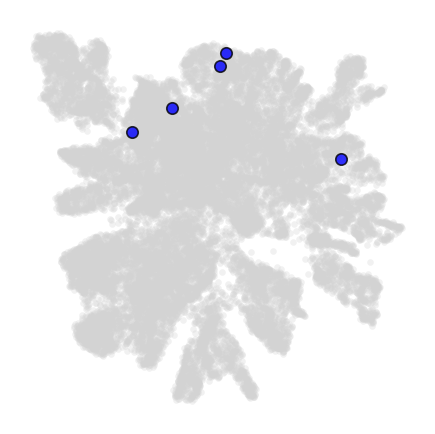

In [34]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = None
)

In [13]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    21774
True         5
Name: count, dtype: int64

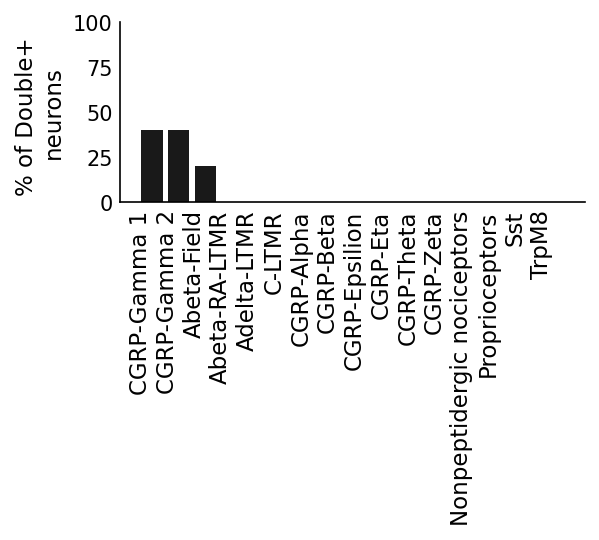

In [14]:
fig = barplot_dual_distribution(adata)

## Export Neuron annotations for Xenium Explorer 
- To get the barcodes to match in xenium explorer, we need to separate into individual Xenium outputs and remove the trailing -0, -1, -2, or -3

In [92]:
adata_neurons_final_labels_draft.obs['sample_id'].unique()

['TMA00317', 'TMA00315', 'TMA00318', 'TMA00316']
Categories (4, object): ['TMA00315', 'TMA00316', 'TMA00317', 'TMA00318']

### Make label annotations df

In [93]:
label_cols = ["sample_id","neuron_label","EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]
label_df = adata_neurons_final_labels_draft.obs[label_cols]

index_clipped = ["-".join(barcode.split('-')[0:2]) for barcode in label_df.index]
label_df.index = index_clipped
label_df = label_df.reset_index(names='cell_id')

In [94]:
label_df.head()

,cell_id,sample_id,neuron_label,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi
0,aaahbdia-1,TMA00317,Nonpeptidergic nociceptors,False,False,False
1,aaakgcko-1,TMA00317,Abeta-RA-LTMR,False,False,False
2,aaanbmpi-1,TMA00317,Nonpeptidergic nociceptors,False,False,False
3,aaangnjd-1,TMA00317,Adelta-LTMR,False,False,False
4,aabakkkd-1,TMA00317,CGRP-Eta,False,False,False


### save neuron labels for Xenium explorer

In [95]:
# for Xenium explorer, can only have one group
label_df_neuron_label = label_df.copy()
label_df_neuron_label['group'] = label_df_neuron_label['neuron_label']

# split to individual samples
label_df_TMA00315 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00315']
label_df_TMA00316 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00316']
label_df_TMA00317 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00317']
label_df_TMA00318 = label_df_neuron_label[label_df_neuron_label['sample_id']=='TMA00318']

# save to csv 
label_df_TMA00315.to_csv('label_df_TMA00315_neuron_label.csv',index=False)
label_df_TMA00316.to_csv('label_df_TMA00316_neuron_label.csv',index=False)
label_df_TMA00317.to_csv('label_df_TMA00317_neuron_label.csv',index=False)
label_df_TMA00318.to_csv('label_df_TMA00318_neuron_label.csv',index=False)

### save reporter group for Xenium explorer




In [96]:
# for Xenium explorer, can only have one group
label_df_reporter = label_df.copy()
label_df_reporter['group'] = 'none'

# add reporter status, either single positive or double postivie
label_df_reporter.loc[label_df_reporter['EGFP_Seq1_hi']==True, 'group'] = 'EGFP_Seq1_hi'
label_df_reporter.loc[label_df_reporter['dTomato_Seq2_hi']==True, 'group'] = 'dTomato_Seq2_hi'
label_df_reporter.loc[label_df_reporter['EGFP_dTomato_dual_hi']==True, 'group'] = 'EGFP_dTomato_dual_hi'

# split to individual samples
label_df_TMA00315 = label_df_reporter[label_df_reporter['sample_id']=='TMA00315']
label_df_TMA00316 = label_df_reporter[label_df_reporter['sample_id']=='TMA00316']
label_df_TMA00317 = label_df_reporter[label_df_reporter['sample_id']=='TMA00317']
label_df_TMA00318 = label_df_reporter[label_df_reporter['sample_id']=='TMA00318']

# save to csv 
label_df_TMA00315.to_csv('label_df_TMA00315_reporter_label.csv',index=False)
label_df_TMA00316.to_csv('label_df_TMA00316_reporter_label.csv',index=False)
label_df_TMA00317.to_csv('label_df_TMA00317_reporter_label.csv',index=False)
label_df_TMA00318.to_csv('label_df_TMA00318_reporter_label.csv',index=False)

In [98]:
# check with sample the double positive cells are in
counts = label_df.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

sample_id  EGFP_dTomato_dual_hi
TMA00316   False                   6076
TMA00315   False                   5954
TMA00318   False                   5046
TMA00317   False                   4698
TMA00316   True                       3
TMA00315   True                       1
TMA00318   True                       1
Name: count, dtype: int64

## Reclassify double positive cells after manual inspection

In [62]:
# load csv with manual reclassification
reclassify_df = pd.read_csv("reporter_label_reclassify.csv")
reclassify_df

,sample_id,barcode,original_label,updated_label
0,TMA00315,ilmfndhn-1,EGFP_dTomato_dual_hi,none
1,TMA00316,jalppfof-1,EGFP_dTomato_dual_hi,none


In [79]:
# update index to include the sample-specific suffic
barcode_matching = adata.obs[['sample_id']].copy()
barcode_matching['suffix'] = [barcode.split('-')[2] for barcode in barcode_matching.index]
barcode_matching = barcode_matching.drop_duplicates().reset_index(drop=True)
suffix_dict = dict(zip(barcode_matching['sample_id'], barcode_matching['suffix']))
reclassify_df.index = reclassify_df['barcode'].astype(str) + "-" + reclassify_df['sample_id'].map(suffix_dict).astype(str)

# reclassify in adata object, first saving original
adata_original = adata.copy()
# will be NaN if no update
adata.obs = adata.obs.join(reclassify_df[['updated_label']])

adata.obs.loc[~adata.obs['updated_label'].isna(), 'EGFP_Seq1_hi']= False
adata.obs.loc[~adata.obs['updated_label'].isna(), 'dTomato_Seq2_hi']= False
adata.obs.loc[~adata.obs['updated_label'].isna(), 'EGFP_dTomato_dual_hi']= False

In [64]:
reclassify_df

,sample_id,barcode,original_label,updated_label
ilmfndhn-1-1,TMA00315,ilmfndhn-1,EGFP_dTomato_dual_hi,none
jalppfof-1-3,TMA00316,jalppfof-1,EGFP_dTomato_dual_hi,none


## Visualize after reclassification

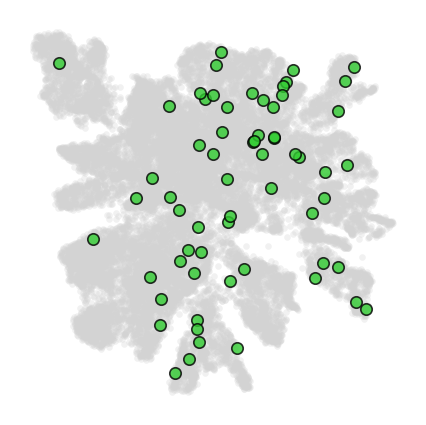

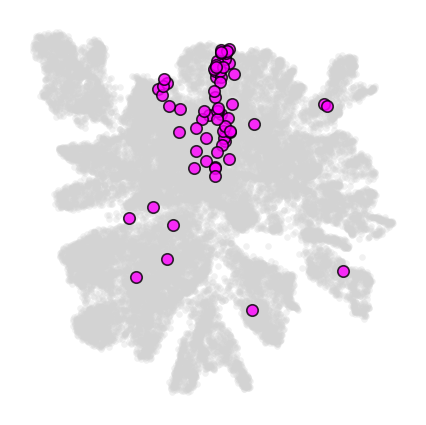

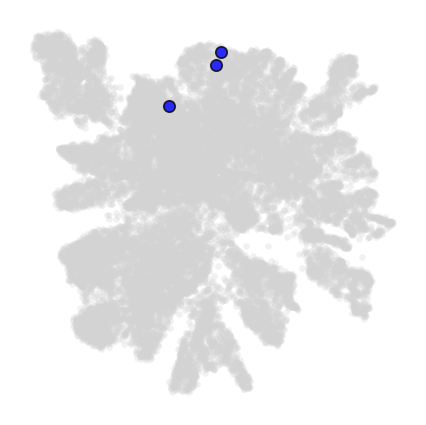

In [105]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = plot_out_dir
)

In [106]:
def plot_gaussian(adata, adata_ref, exclude_barcodes=None, save_path = None):
    adata = adata.copy()
    adata_ref = adata_ref.copy()

    adata_list = [adata, adata_ref]
    for ad in adata_list:
        ad.var_names = ad.var_names.where(ad.var_names != "tdTomato_Seq2", "dTomato_Seq2")

    adata.X = adata.layers["counts"].copy()
    adata_ref.X = adata_ref.layers["counts"].copy()
    
    genes = ["EGFP_Seq1", "dTomato_Seq2"]
    
    # Raw counts for filtering
    egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
    td_raw_all = to_dense(adata_ref[:, "dTomato_Seq2"].X)
    
    # Filter to include only cells with >1 raw count in both genes
    bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)
    
    gauss_results = {}
    for g in genes:
        x_raw_full = to_dense(adata_ref[:, g].X)
        x_raw = x_raw_full[bg_filter]
        x_log = np.log1p(x_raw)

        mu, sigma = np.mean(x_log), np.std(x_log)
        thr_log = mu + 2.326 * sigma
        
        hi_mask = np.zeros(adata_ref.n_obs, dtype=bool)
        hi_mask[bg_filter] = x_log > thr_log
        adata_ref.obs[f"{g}_hi"] = hi_mask
        gauss_results[g] = {"x_log": x_log, "thr_log": thr_log}
    
    # Identify Dual-high
    adata_ref.obs["EGFP_dTomato_dual_hi"] = (
        adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
    )
    
    # --- New Logic for Manual Exclusion ---
    # Create a mask for excluded cells within the filtered background
    is_excluded = np.zeros(adata_ref.n_obs, dtype=bool)
    if exclude_barcodes is not None:
        is_excluded = adata_ref.obs_names.isin(exclude_barcodes)
    
    # Subsets for plotting (only for cells that passed bg_filter)
    dual_mask = adata_ref.obs["EGFP_dTomato_dual_hi"][bg_filter].values
    excluded_mask = is_excluded[bg_filter]
    
    # Only color as "Dual" if it is dual-high AND NOT excluded
    final_dual = dual_mask & ~excluded_mask
    # Only color as "Excluded" if it was dual-high but is in our list
    final_excluded = dual_mask & excluded_mask
    # --------------------------------------

    x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
    x_td_log = gauss_results["dTomato_Seq2"]["x_log"]
    thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
    thr_td_log = gauss_results["dTomato_Seq2"]["thr_log"]

    # Plot
    sns.set_theme(style="ticks")
    plt.figure(figsize=(4, 4), dpi=300)
    ax = plt.gca()
    
    # 1. Background (Gray)
    ax.scatter(x_egfp_log, x_td_log, s=3, color="gray", alpha=0.15, label="Background")
    
    # 2. Confirmed Dual High (Blue)
    ax.scatter(
        x_egfp_log[final_dual],
        x_td_log[final_dual],
        s=40, facecolors=(0.0, 0.47, 1.0, 0.45), edgecolors="blue", linewidths=1, label="Dual Positive"
    )
    
    # 3. Manual Reclassified / Excluded (Orange)
    if final_excluded.any():
        ax.scatter(
            x_egfp_log[final_excluded],
            x_td_log[final_excluded],
            s=40, facecolors=(0.3, 0.3, 0.3, 0.6), edgecolors="gray", linewidths=1, label="Reclassified"
        )
    
    ax.axvline(thr_egfp_log, color="red", ls="--", lw=1.5)
    ax.axhline(thr_td_log, color="red", ls="--", lw=1.5)
    
    ax.set_xlabel("log1p EGFP")
    ax.set_ylabel("log1p dTomato")
    # ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    
    sns.despine()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(os.path.join(save_path, "gaussian_reclassified.png"), format='png', bbox_inches='tight')
    plt.show()

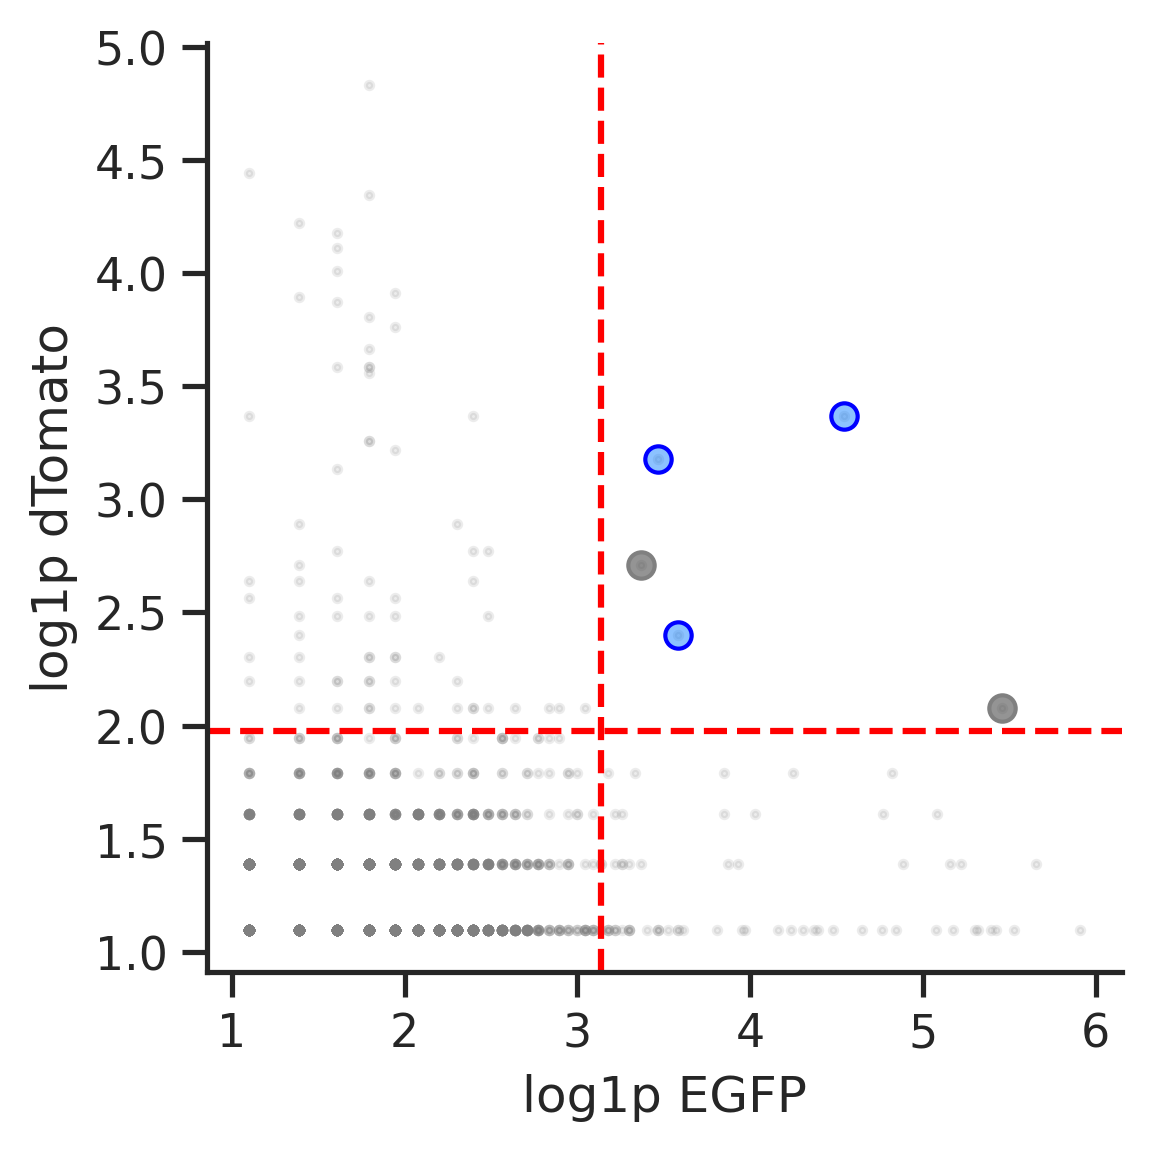

In [107]:
plot_gaussian(adata, adata_ref, exclude_barcodes=reclassify_df.index.tolist(),
             save_path = plot_out_dir)

In [113]:
counts = adata.obs.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

sample_id  EGFP_dTomato_dual_hi
TMA00316   False                   6077
TMA00315   False                   5955
TMA00318   False                   5046
TMA00317   False                   4698
TMA00316   True                       2
TMA00318   True                       1
Name: count, dtype: int64

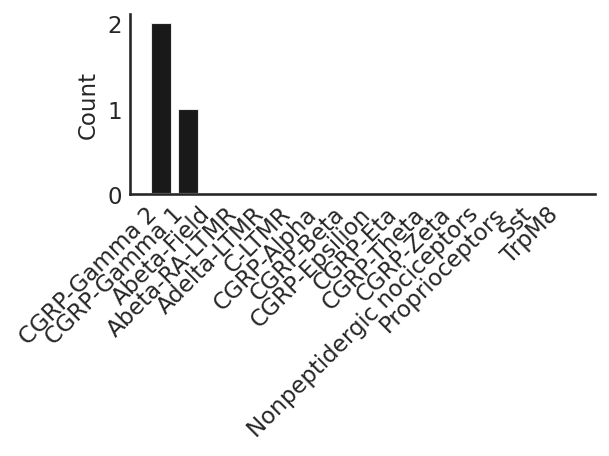

In [120]:
fig = barplot_dual_distribution(adata, plot_counts = True)
plt.savefig(os.path.join(plot_out_dir, "dual_distribution.png"), format='png', bbox_inches='tight')

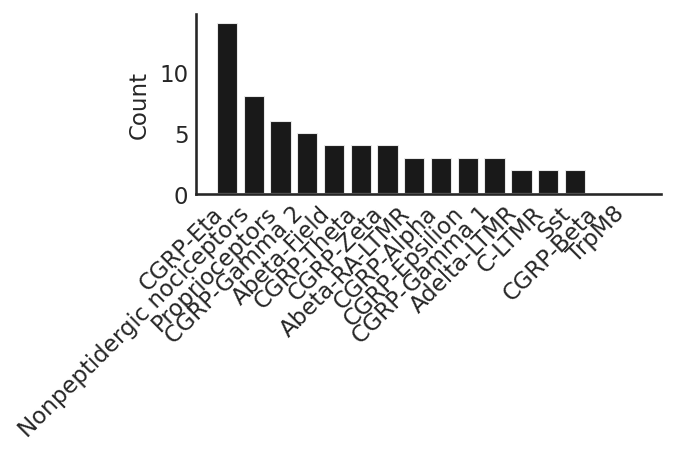

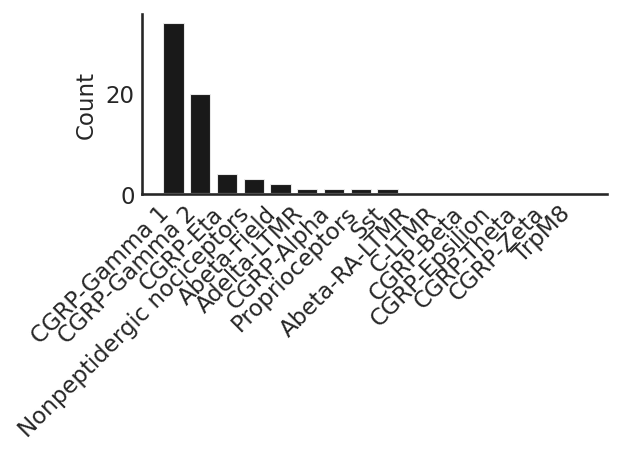

In [122]:
barplot_dual_distribution(adata,dual_col="EGFP_Seq1_hi")
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution.png"), format='png', bbox_inches='tight')

barplot_dual_distribution(adata,dual_col="dTomato_Seq2_hi")
plt.savefig(os.path.join(plot_out_dir, "Tomato_distribution.png"), format='png', bbox_inches='tight')